<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   order_id    9994 non-null   object        
 1   order_date  9994 non-null   datetime64[ns]
 2   ship_mode   9994 non-null   object        
 3   segment     9994 non-null   object        
 4   region      9994 non-null   object        
 5   category    9994 non-null   object        
 6   sales       9994 non-null   float64       
 7   quantity    9994 non-null   int64         
 8   profit      9994 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(5)
memory usage: 702.8+ KB


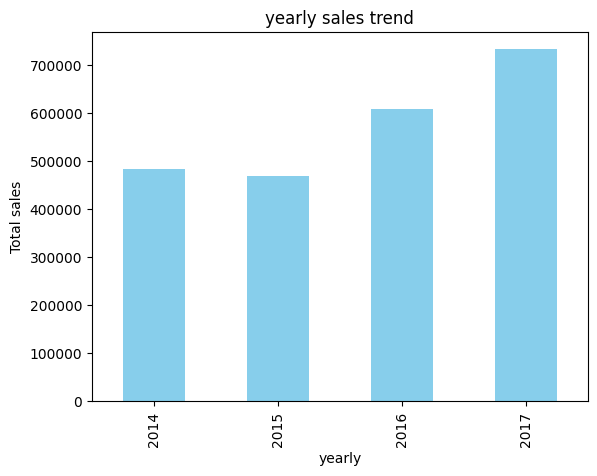

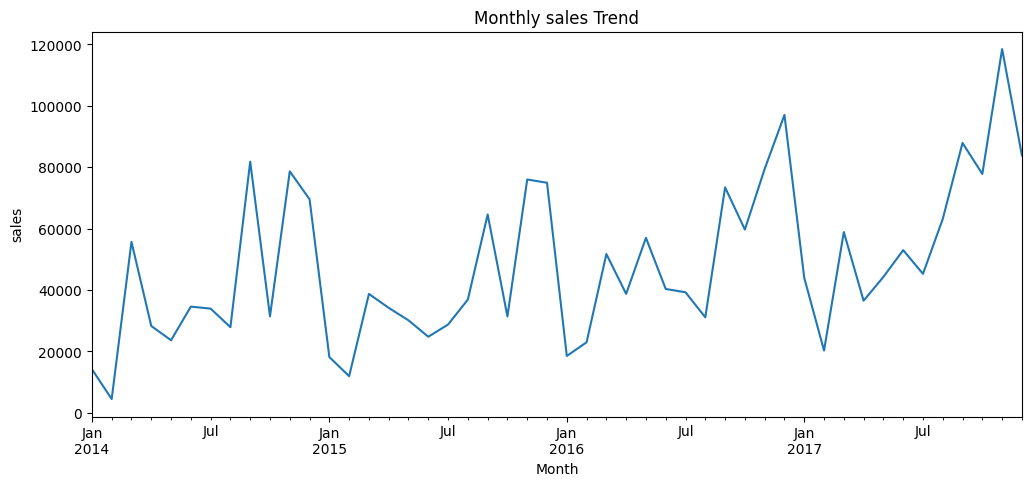

region
Central    501239.8908
East       678781.2400
South      391721.9050
West       725457.8245
Name: sales, dtype: float64


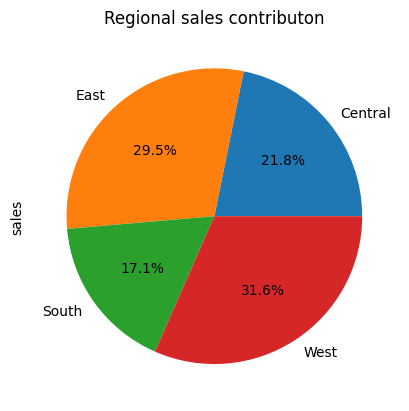

                       sales        profit  profit_margin
category                                                 
Furniture        741999.7953   18451.27279       2.486695
Office Supplies  719047.0320  122490.80080      17.035158
Technology       836154.0330  145454.94810      17.395712


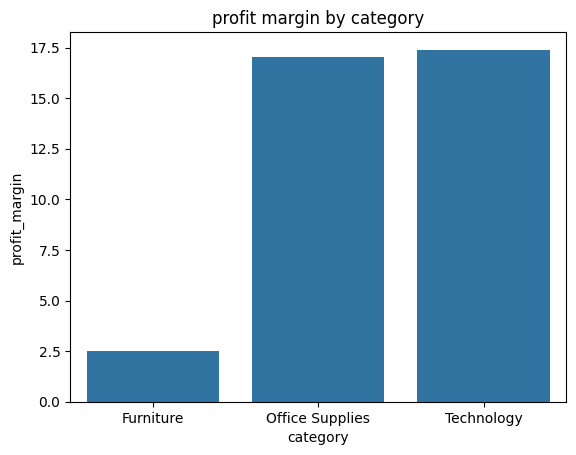

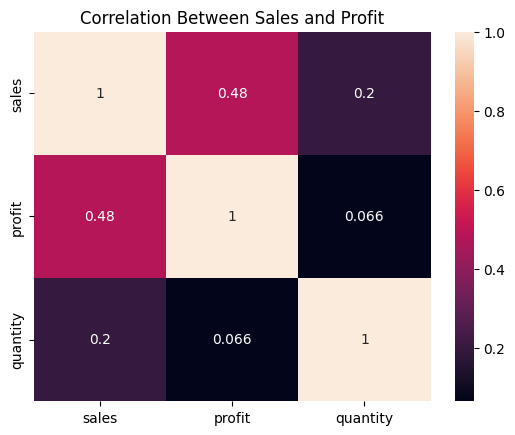

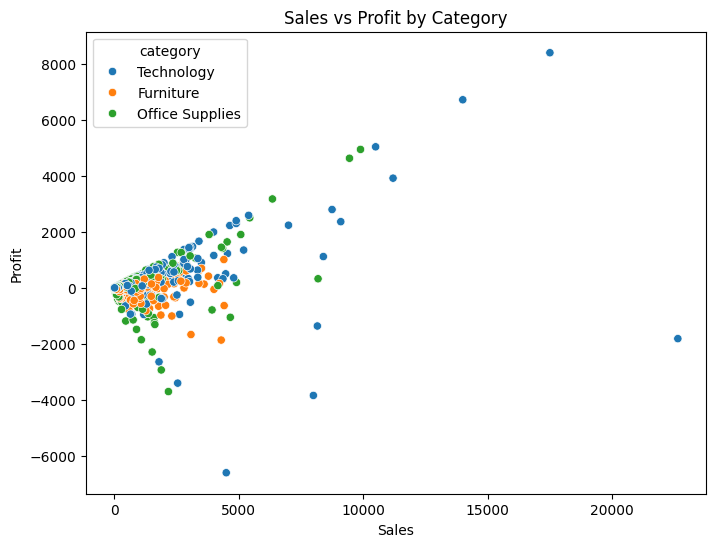

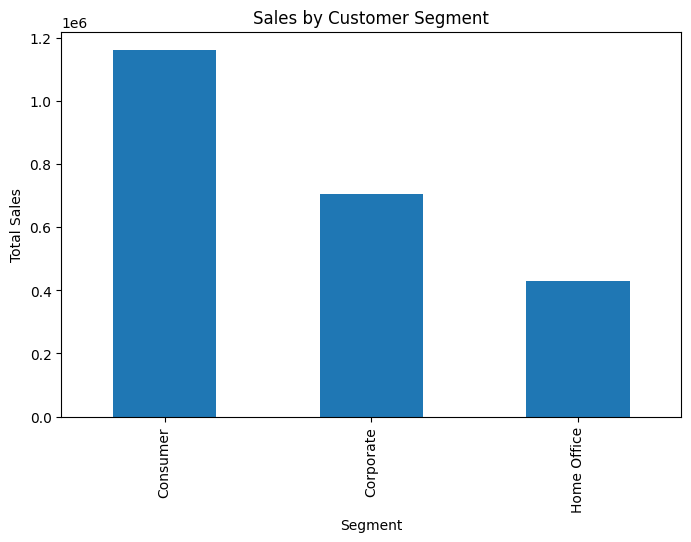

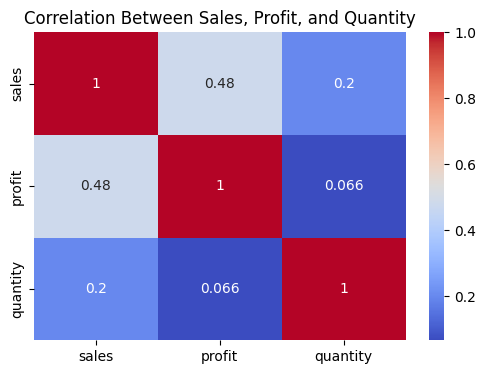

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df= pd.read_csv("orders_rows.csv")
df.head()
df["order_date"]=pd.to_datetime(df["order_date"])
df.info()
yearly_sales=df.groupby(df["order_date"].dt.year)["sales"].sum()
yearly_sales.plot(kind="bar",color="skyblue")
plt.title("yearly sales trend")
plt.xlabel("yearly")
plt.ylabel("Total sales")
plt.savefig("yearly_sales.png")
plt.show()

monthly_sales= df.groupby(df["order_date"].dt.to_period("M"))["sales"].sum()
monthly_sales.plot(figsize=(12,5))
plt.title("Monthly sales Trend")
plt.xlabel("Month")
plt.ylabel("sales")
plt.savefig("Monthly sales Trend.png")
plt.show()

region_sales= df.groupby("region")["sales"].sum()
print(region_sales)

region_sales.plot(kind="pie",autopct="%1.1f%%")
plt.title("Regional sales contributon")
plt.savefig("Regional Sales contribution.png")
plt.show()

category= df.groupby("category")[["sales","profit"]].sum()
category["profit_margin"]= category["profit"]/category["sales"]*100
print(category)

sns.barplot(x=category.index,y=category["profit_margin"])
plt.title("profit margin by category")
plt.savefig("profit margin by category.png")
plt.show()

top_orders= df.sort_values(by="sales",ascending=False).head(10)
top_orders[["order_id","category","sales"]]


df[["sales","profit","quantity"]].corr()
sns.heatmap(df[["sales","profit","quantity"]].corr(), annot=True)
plt.title("Correlation Between Sales and Profit")
plt.savefig("Correlation Between Sales and Profit.png")
plt.show()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="sales", y="profit", hue="category")

plt.title("Sales vs Profit by Category")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.savefig("Sales vs Profit by Category.png")
plt.show()
segment_sales = df.groupby("segment")["sales"].sum()

plt.figure(figsize=(8,5))
segment_sales.plot(kind="bar")

plt.title("Sales by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Total Sales")
plt.savefig("Sales by Customer Segment.png")
plt.show()
top_profit = df.sort_values(by="profit", ascending=False).head(10)

top_profit[["order_id","category","sales","profit"]]
plt.figure(figsize=(6,4))

sns.heatmap(df[["sales","profit","quantity"]].corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Between Sales, Profit, and Quantity")
plt.savefig ("Correlation Between Sales,Profit and Quantity.png")
plt.show()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Higher sales generally lead to higher profit.
Technology category shows strong profit generation.
Some transactions show high sales but low profit.

# Key Findings

1. Sales grew from $484K in 2014 to $733K in 2017.
2. West region contributes the largest share of revenue.
3. Technology category has the highest profit margin.
4. Furniture generates revenue but has low profitability.

### Insight

The West region contributes the highest share of sales (≈31%).  
The South region has the lowest revenue contribution.

### Insight

Sales increased significantly from 2014 to 2017.

2014 Sales: $484K  
2017 Sales: $733K  

This indicates a growth of approximately 51%, showing strong business expansion.

# Retail Sales Data Analysis

Dataset: Superstore Orders Dataset  
Records: 9,994 transactions

Objective:
Analyze sales trends, regional performance, and product profitability.